In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_filtered_features_3lakh.csv')
df.head()

,text,Label,filtered_text_eng,tokenized_text,Preprocessed_Text,filtered_tokenized_words
0,"I'm done with it all. Any tips?First of all, i...",2,done with it Any of if going to comment get or...,"['done', 'go', 'comment', 'get', 'plea', 'unde...",done go comment get plea understand want hear ...,"['kill', 'pain', 'sorri', 'hate']"
1,i 20m was a problem child when grow up i frequ...,1,i was a problem child when grow up i frequent ...,"['problem', 'child', 'grow', 'frequent', 'got'...",problem child grow frequent got troubl junior ...,"['ill', 'awkward', 'steal', 'silenc', 'wrong',..."
2,I officially hate my school We have to start p...,0,I officially hate my school We have to start o...,"['offici', 'hate', 'school', 'start', 'enter',...",offici hate school start enter caus fix,"['offici', 'hate', 'school', 'start', 'enter',..."
3,but onc again depress love to take that from m...,1,but onc again depress love to take that from m...,"['onc', 'depress', 'love', 'take', 'angri', 'w...",onc depress love take angri want cri wont come...,"['cri', 'angri', 'damn', 'tire', 'depress']"
4,"Starting today, I'm going to attempt to fix my...",0,Starting going to attempt to fix my sleep sche...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc...",start go attempt fix sleep schedul school coup...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc..."


In [3]:
df1 = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_all_features.csv')
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,2781,2782,2783,2784,2785,2786,2787,2788,2789,2790
0,-0.311691,0.207526,0.294796,-0.370256,-0.463946,0.004523,0.103642,0.023245,-0.273210,-0.043930,...,1.174970,-0.131030,0.581713,1.317829,0.545300,-4.912285,2.002302,-2.429308,2.313626,0.068317
1,-0.314458,0.200302,0.248307,-0.337924,-0.354438,-0.029178,0.120759,0.028209,-0.381361,-0.010982,...,-0.170022,-1.057125,0.506787,0.481089,-0.443753,-1.015673,0.295432,-1.521313,-0.511028,-0.270724
2,-0.258834,0.199409,0.255281,-0.329083,-0.421285,-0.008494,0.122459,0.000529,-0.345936,-0.007731,...,-0.475023,-2.049421,-2.095686,-2.270150,2.747774,-4.004583,-1.818186,-3.040991,-0.021306,1.718746
3,-0.348873,0.164237,0.313819,-0.395596,-0.340182,-0.008542,0.077583,-0.002947,-0.369009,0.005620,...,1.116820,0.496508,2.048395,-0.856290,0.582634,-1.573221,0.650254,-1.483610,0.080408,-0.893238
4,-0.258569,0.201524,0.242732,-0.321395,-0.432100,-0.044947,0.111697,0.009705,-0.350573,-0.033735,...,-0.861691,-1.552952,-0.070507,-2.612564,0.754670,-5.594344,3.663493,-0.440785,1.437596,-0.616004


In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [5]:
# Apply PCA
pca = PCA(n_components=100, random_state=42)
X = pca.fit_transform(X_scaled)

In [6]:
y = df['Label'].values

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = True)

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [8]:
# Define the path to the directory
save_directory = "E:/Works/10. Mental Health Disorder/Plots/FT-Transformer"

# Ensure the directory exists
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

In [9]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 4070 Laptop GPU


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import time

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define a Transformer model for tabular data
class TabularTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=512, num_heads=8, num_layers=2, dropout=0.1):
        super(TabularTransformer, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.embedding = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Convert input features to embeddings
        x = self.embedding(x)
        # Transformer expects format: (batch_size, seq_len, embedding_dim)
        x = x.unsqueeze(1)
        x = self.transformer_encoder(x)
        # Pooling across the sequence length (axis 1)
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Convert numpy arrays to tensors and move to device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Initialize datasets and loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, loss function, optimizer, scheduler
input_dim = X_train.shape[1]
output_dim = len(np.unique(y_train))
model = TabularTransformer(input_dim, output_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# Training loop with timing
epochs = 50
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == batch_y).sum().item()
        total_train_samples += batch_y.size(0)

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_accuracy = correct_train_predictions / total_train_samples
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    model.eval()
    epoch_val_loss = 0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val_predictions += (predicted == batch_y).sum().item()
            total_val_samples += batch_y.size(0)

    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_accuracy = correct_val_predictions / total_val_samples
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_accuracy:.4f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

end_time = time.time()

Using device: cuda
Epoch 1/50, Train Loss: 0.2616, Train Accuracy: 0.8962, Val Loss: 0.2378, Val Accuracy: 0.9033
Epoch 2/50, Train Loss: 0.2380, Train Accuracy: 0.9028, Val Loss: 0.2313, Val Accuracy: 0.9074
Epoch 3/50, Train Loss: 0.2327, Train Accuracy: 0.9053, Val Loss: 0.2364, Val Accuracy: 0.9013
Epoch 4/50, Train Loss: 0.2294, Train Accuracy: 0.9055, Val Loss: 0.2338, Val Accuracy: 0.9030
Epoch 5/50, Train Loss: 0.2279, Train Accuracy: 0.9064, Val Loss: 0.2290, Val Accuracy: 0.9075
Epoch 6/50, Train Loss: 0.2278, Train Accuracy: 0.9061, Val Loss: 0.2240, Val Accuracy: 0.9067
Epoch 7/50, Train Loss: 0.2263, Train Accuracy: 0.9067, Val Loss: 0.2209, Val Accuracy: 0.9068
Epoch 8/50, Train Loss: 0.2247, Train Accuracy: 0.9069, Val Loss: 0.2174, Val Accuracy: 0.9091
Epoch 9/50, Train Loss: 0.2246, Train Accuracy: 0.9071, Val Loss: 0.2187, Val Accuracy: 0.9081
Epoch 10/50, Train Loss: 0.2245, Train Accuracy: 0.9073, Val Loss: 0.2169, Val Accuracy: 0.9085
Epoch 11/50, Train Loss: 0.223

In [11]:
training_time_minutes = (end_time - start_time) / 60
print(f"\nTraining completed in {training_time_minutes:.2f} minutes")


Training completed in 62.26 minutes


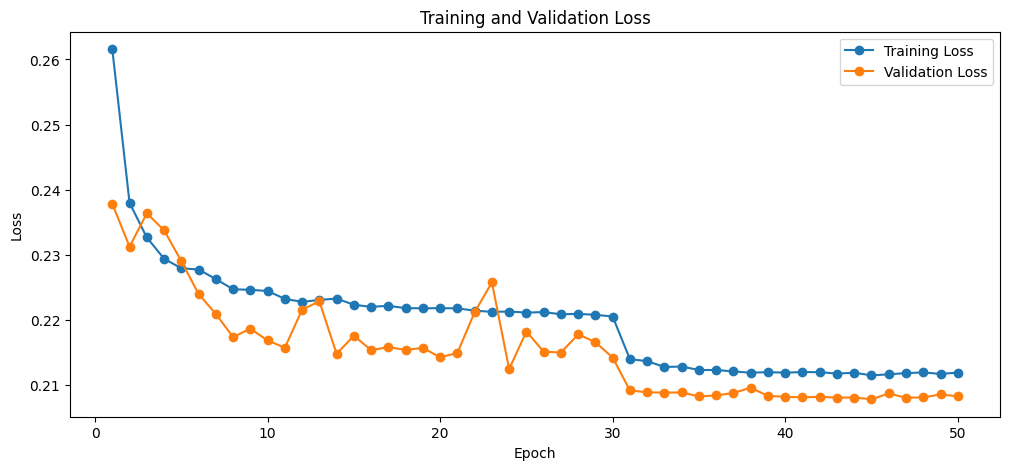

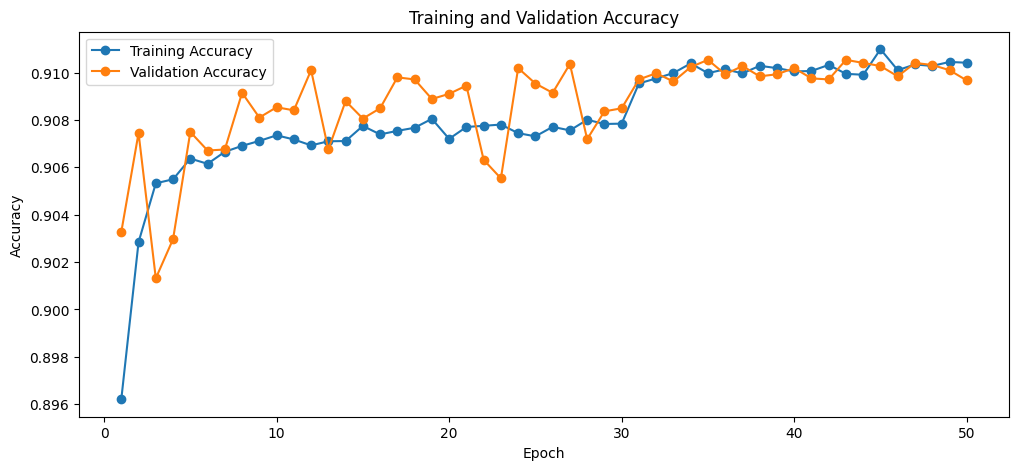

In [12]:
# Plot training and validation loss curves
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig(os.path.join(save_directory, "loss_curve_ft_transformer.png"))
plt.show()

# Plot training and validation accuracy curves
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', label='Training Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.savefig(os.path.join(save_directory, "accuracy_curve_ft_transformer.png"))
plt.show()

In [13]:
# Set the model to evaluation mode
model.eval()

# Lists to store predictions, labels, and probabilities
all_preds_ft = []
all_labels_ft = []
all_probs_ft = []

# No gradient computation is needed during evaluation
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # Forward pass
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1)  
        _, preds = torch.max(outputs, 1)  
        
        # Store the predictions, labels, and probabilities
        all_preds_ft.extend(preds.cpu().tolist())
        all_labels_ft.extend(batch_y.cpu().tolist())
        all_probs_ft.extend(probs.cpu().tolist())

# Convert the collected lists to PyTorch tensors
all_preds_ft = torch.tensor(all_preds_ft)
all_labels_ft = torch.tensor(all_labels_ft)
all_probs_ft = torch.tensor(all_probs_ft)

# Calculate the accuracy
accuracy_ft = (all_preds_ft == all_labels_ft).float().mean().item()

# Convert tensors to lists for generating the classification report
y_true = all_labels_ft.tolist()
y_pred = all_preds_ft.tolist()

# Generate the classification report
report_ft = classification_report(y_true, y_pred)
print(report_ft)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.87      0.86      0.87     19373
           2       0.85      0.87      0.86     18358

    accuracy                           0.91     57480
   macro avg       0.91      0.91      0.91     57480
weighted avg       0.91      0.91      0.91     57480



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_confusion_matrix(model_name, conf_matrix, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.arange(conf_matrix.shape[1]),
                yticklabels=np.arange(conf_matrix.shape[0]))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.savefig(os.path.join(save_path, f"{model_name}_confusion_matrix.png"))  
    plt.show() 
    plt.close() 

def plot_roc_curve(model_name, y_true, y_prob, save_path, num_classes):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Binarize the labels for multi-class ROC AUC
    y_true_binarized = label_binarize(y_true, classes=range(num_classes))
    n_classes = y_true_binarized.shape[1]
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = plt.get_cmap('tab10') 
    total_auc = 0

    # Ensure y_prob is a 2D numpy array
    y_prob = np.array([np.pad(prob, (0, num_classes - len(prob)), mode='constant') for prob in y_prob])

    # Calculate ROC metrics and plot
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        y_test_bin = y_true_binarized[:, i]
        y_prob_class = y_prob[:, i]
        fpr[i], tpr[i], _ = roc_curve(y_test_bin, y_prob_class)
        roc_auc[i] = auc(fpr[i], tpr[i])
        total_auc += roc_auc[i]
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                 label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')

    avg_auc = total_auc / n_classes
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(save_path, f"{model_name}_roc_curve.png")) 
    plt.show()  
    plt.close() 

    return avg_auc

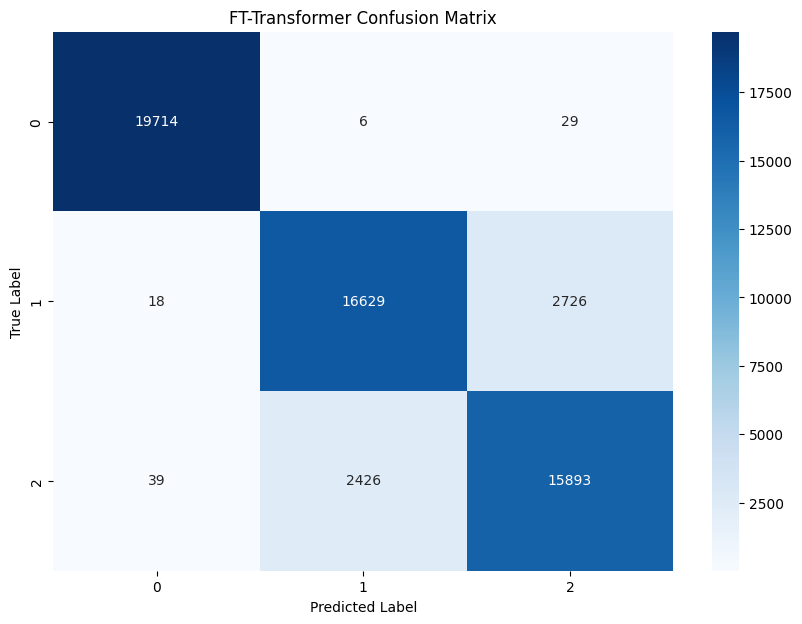

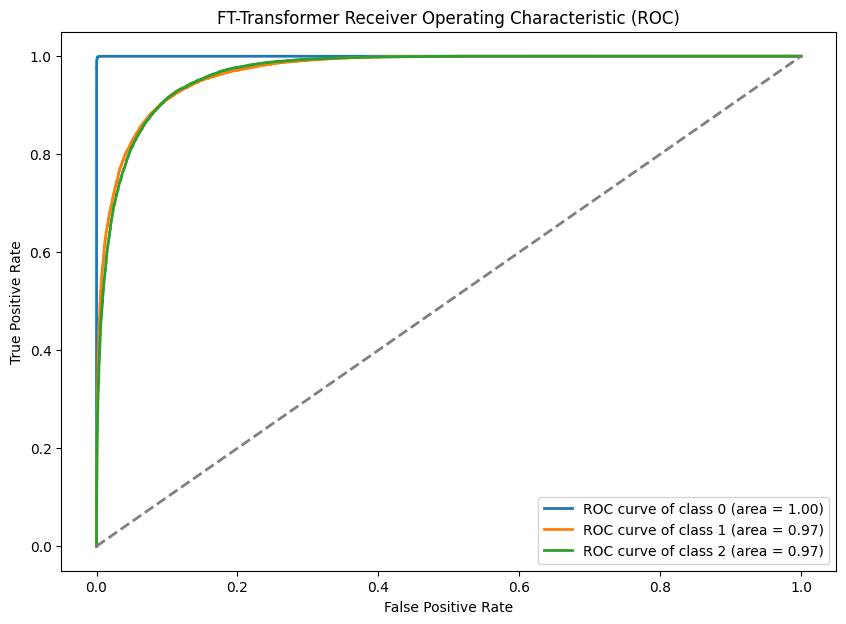

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.87      0.86      0.87     19373
           2       0.85      0.87      0.86     18358

    accuracy                           0.91     57480
   macro avg       0.91      0.91      0.91     57480
weighted avg       0.91      0.91      0.91     57480

Average ROC AUC Score: 0.9799


In [15]:
# Convert tensors to lists
y_true = all_labels_ft.tolist()
y_pred = all_preds_ft.tolist()
y_prob = [prob.tolist() for prob in all_probs_ft]  # Convert tensors to lists of lists

# Number of classes
num_classes = output_dim

# Compute confusion matrix
conf_matrix_ft = confusion_matrix(y_true, y_pred)

# Plot and save the confusion matrix
plot_confusion_matrix("FT-Transformer", conf_matrix_ft, save_directory)

# Compute ROC AUC
roc_auc_ft = plot_roc_curve("FT-Transformer", y_true, y_prob, save_directory, num_classes)

# Generate and print classification report
report_ft = classification_report(y_true, y_pred)
print(f"Classification Report:\n{report_ft}")

print(f"Average ROC AUC Score: {roc_auc_ft:.4f}")